# Transition tables from one big CSV

In [11]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

# Optional Colab setup for LaTeX rendering
# !apt-get update
# !apt-get install -y texlive-latex-base texlive-latex-extra texlive-fonts-recommended texlive-fonts-extra dvipng cm-super

# Keep plain-text rendering for table labels like "Safe (B&B)".
USE_TEX = False

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "axes.linewidth": 1.2,
    "figure.dpi": 160,
    "savefig.dpi": 300,
})

plt.rcParams.update({
    "text.usetex": USE_TEX,
    "mathtext.fontset": "cm",
})

if USE_TEX:
    plt.rcParams.update({
        "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
    })

def resolve_notebook_dir():
    for root in [Path.cwd(), *Path.cwd().parents]:
        if (root / "transition_tables_vggnet.ipynb").exists():
            return root.resolve()
        if (root / "analysis/transition/transition_tables_vggnet.ipynb").exists():
            return (root / "analysis/transition").resolve()
    return Path.cwd().resolve()

NOTEBOOK_DIR = resolve_notebook_dir()

def resolve_csv_path():
    candidates = [NOTEBOOK_DIR / "combined_results.csv"]
    for root in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        candidates.extend([
            root / "analysis/transition/combined_results.csv",
            root / "results/vggnet16/all_k_vggnet16.csv",
            root / "results/vggnet16/combined_results.csv",
        ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists():
            return candidate

    tried = "\n".join(str(path) for path in seen)
    raise FileNotFoundError(f"Could not find the VGG transition CSV. Tried:\n{tried}")

csv_path = resolve_csv_path()
print(f"Loading CSV: {csv_path}")
df = pd.read_csv(csv_path)

Loading CSV: /Users/zd3504phd/Desktop/XAIV/results/vggnet16/all_k_vggnet16.csv


In [12]:
def tag_to_semantic(t):
    t=str(t).lower()
    if "global" in t: return "Global"
    if "fix_mask" in t : return "Background"
    if "fix_nonmask" in t: return "Object"
    return "Unknown"
df["semantic"]=df["tag"].apply(tag_to_semantic)

In [13]:
import numpy as np
import pandas as pd

# -------------------------
# 1) Clean k/eps (coerce to numeric), and drop junk rows
# -------------------------
df = df.copy()

# If k/eps are strings sometimes, this will convert numeric strings and set bad ones to NaN
df["k_num"]   = pd.to_numeric(df["k"], errors="coerce")
df["eps_num"] = pd.to_numeric(df["eps"], errors="coerce")

# Drop rows where k or eps failed to parse (this will remove the 'k/eps' header row)
df = df.dropna(subset=["k_num", "eps_num"]).copy()

# Optional: enforce integer k (since yours should be 50176 etc.)
df["k_num"] = df["k_num"].astype(int)

# If you want to overwrite columns cleanly:
df["k"] = df["k_num"]
df["eps"] = df["eps_num"]

# -------------------------
# 2) (Optional) Restrict semantic to expected values
# -------------------------
allowed_semantics = {"Global", "Object", "Background"}  # add "Unknown" only if it's a real semantic category
df = df[df["semantic"].isin(allowed_semantics)].copy()

# -------------------------
# 3) Build the groupby table again
# -------------------------
big = (
    df.groupby(["k", "eps", "semantic"])
      .size()
      .unstack("semantic", fill_value=0)
      .sort_index()
)

display(big)

# -------------------------
# 4) Quick sanity checks
# -------------------------
print("Unique k:", sorted(df["k"].unique())[:10], " ...")
print("Unique eps:", sorted(df["eps"].unique())[:10], " ...")
print("Any non-numeric k/eps left?",
      df["k"].isna().any(), df["eps"].isna().any())

,semantic,Background,Global,Object
k,eps,,,
1568,0.0001,181,181,181
3136,0.0001,181,181,181
6272,0.0001,181,181,181
12544,0.0001,181,181,181
25088,0.0001,181,181,181
50176,0.0001,181,181,181


Unique k: [np.int64(1568), np.int64(3136), np.int64(6272), np.int64(12544), np.int64(25088), np.int64(50176)]  ...
Unique eps: [np.float64(0.0001)]  ...
Any non-numeric k/eps left? False False


In [14]:
import numpy as np
import pandas as pd

# ---------- 1) Make numeric columns truly numeric ----------
# (This will turn "0", "1.0", etc into numbers and junk like "k" into NaN)
domains = pd.to_numeric(df["domains_visited"], errors="coerce").fillna(0)
lb      = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")  # keep NaN if unparseable

bab_used  = domains > 0
lb_is_nan = lb.isna()
lb_is_minf = np.isneginf(lb.to_numpy(dtype=float, na_value=np.nan))  # robust

# ---------- 2) Normalize result strings ----------
res = df["result"].astype(str).str.lower().str.strip()

def compute_status(i: int) -> str:
    r = res.iat[i]
    bab = bool(bab_used.iat[i])
    minf = bool(lb_is_minf[i])   # lb_is_minf is numpy array
    nan  = bool(lb_is_nan.iat[i])

    # SAFE (UNSAT)
    if r.startswith("unsat"):
        return "Safe with branch-and-bound" if bab else "Safe via initial bounding"

    # UNSAFE (SAT)
    if r.startswith("sat"):
        # you can keep/adjust this rule; I'm keeping your intention:
        if (not bab) and (not minf) and (not nan):
            return "Counterexample found immediately"
        else:
            return "Counterexample found during initial bounding/attack"

    # UNKNOWN / timeout
    if ("timeout" in r) or ("unknown" in r):
        return "Unknown with branch-and-bound" if bab else "Unknown without branch-and-bound"

    return "Other/Unparsed"

df["status"] = [compute_status(i) for i in range(len(df))]

# ---------- 3) Optional sanity prints ----------
print("domains_visited dtype (raw):", df["domains_visited"].dtype)
print("domains_visited numeric min/max:", float(domains.min()), float(domains.max()))
print(df["status"].value_counts(dropna=False))

domains_visited dtype (raw): float64
domains_visited numeric min/max: 0.0 3.0
status
Counterexample found during initial bounding/attack    1701
Safe via initial bounding                              1397
Unknown with branch-and-bound                           115
Unknown without branch-and-bound                         24
Safe with branch-and-bound                               21
Name: count, dtype: int64


In [15]:
df["domains_visited"] = pd.to_numeric(df["domains_visited"], errors="coerce")
df["lb_minus_rhs"]    = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")

In [16]:
# ---- Collapse to 3 labels for paper
STATUS_SHORT = {
    "Counterexample found immediately": "Unsafe",
    "Counterexample found during initial bounding/attack": "Unsafe",
    "Safe via initial bounding": "Safe",
    "Safe with branch-and-bound": "Safe",
    "Unknown with branch-and-bound": "Unknown",
    "Unknown without branch-and-bound": "Unknown",
    "safe with branch-and-bound": "Safe",  # in case of capitalization differences
    "Other/Unparsed": "Unknown",
}

# Apply mapping (keep original too)
df["status_short"] = df["status"].map(STATUS_SHORT).fillna(df["status"])



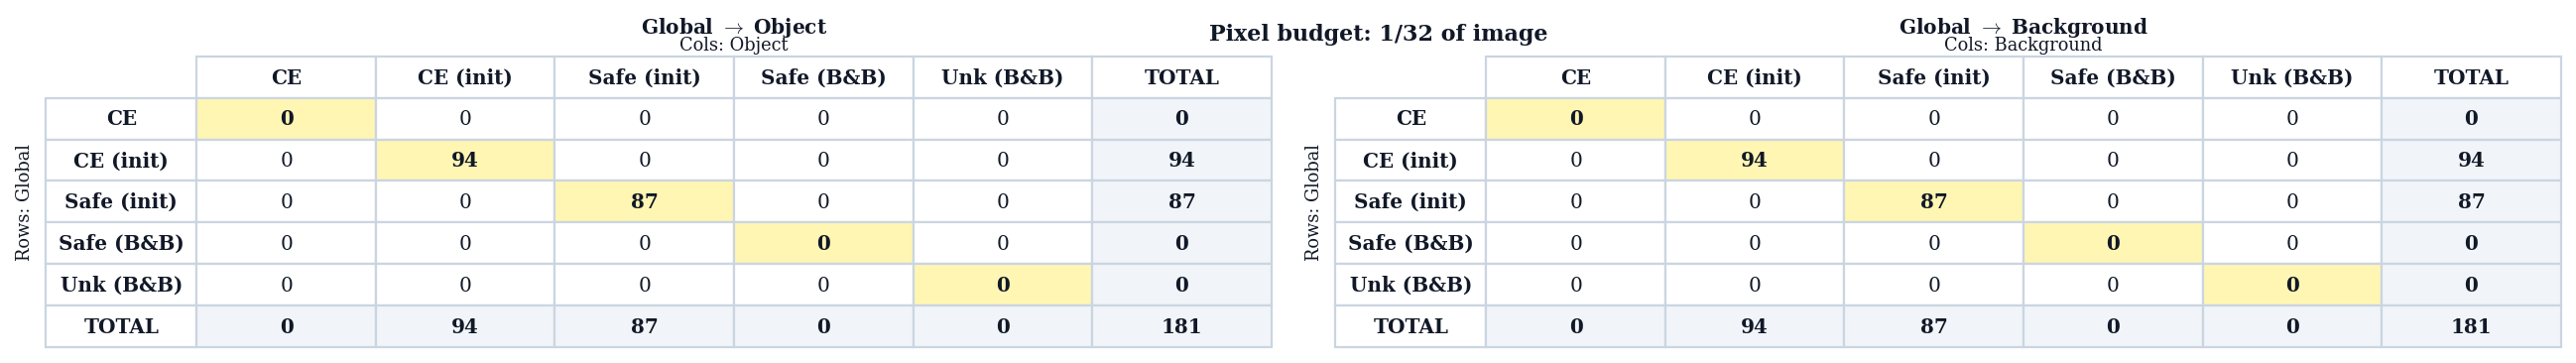

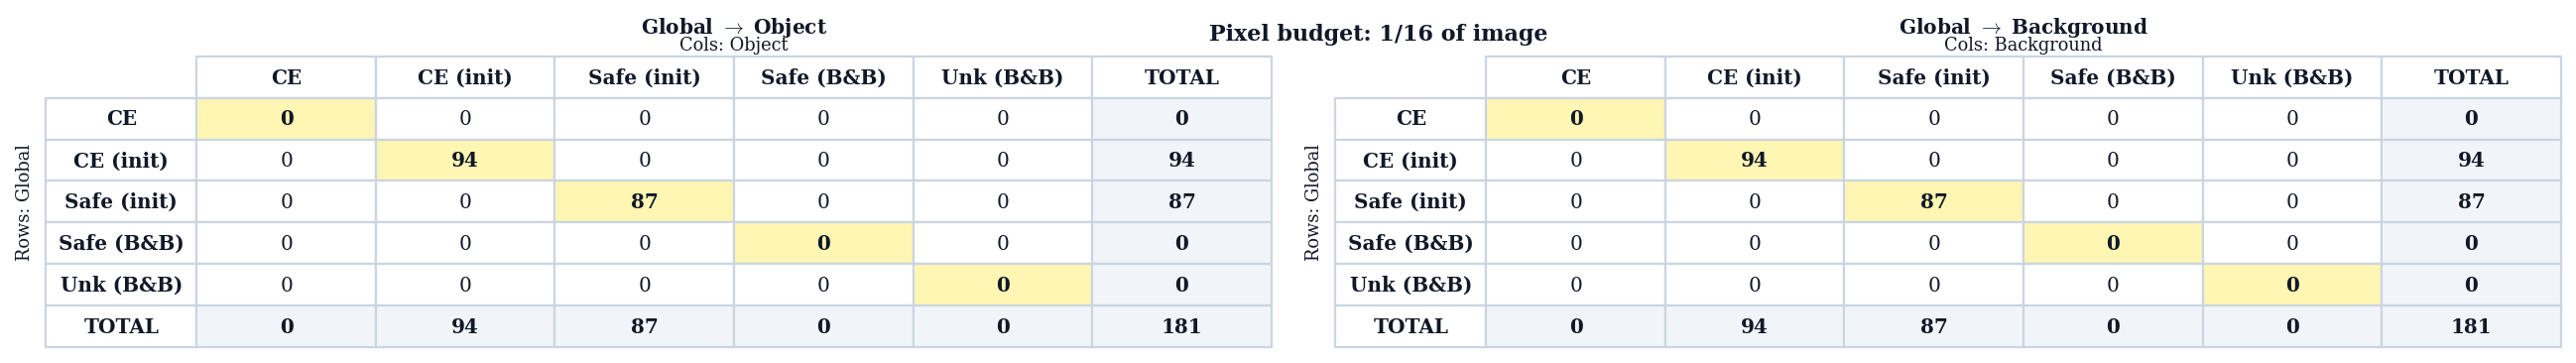

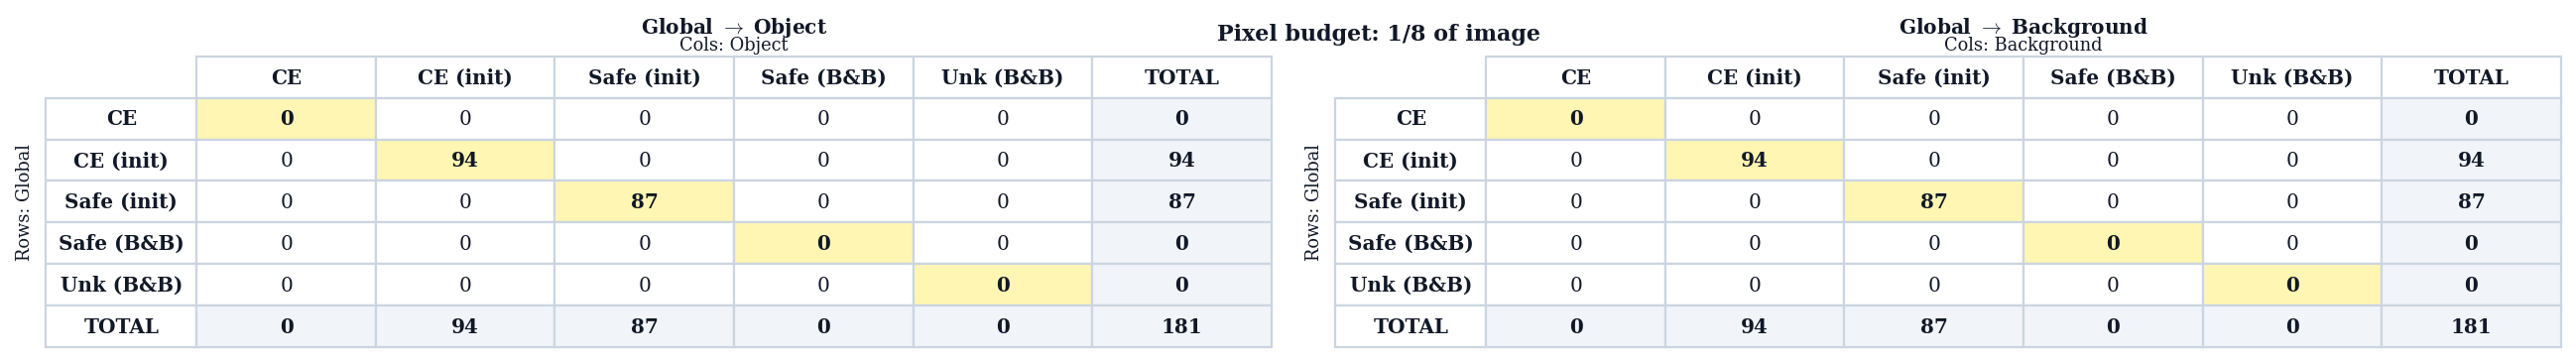

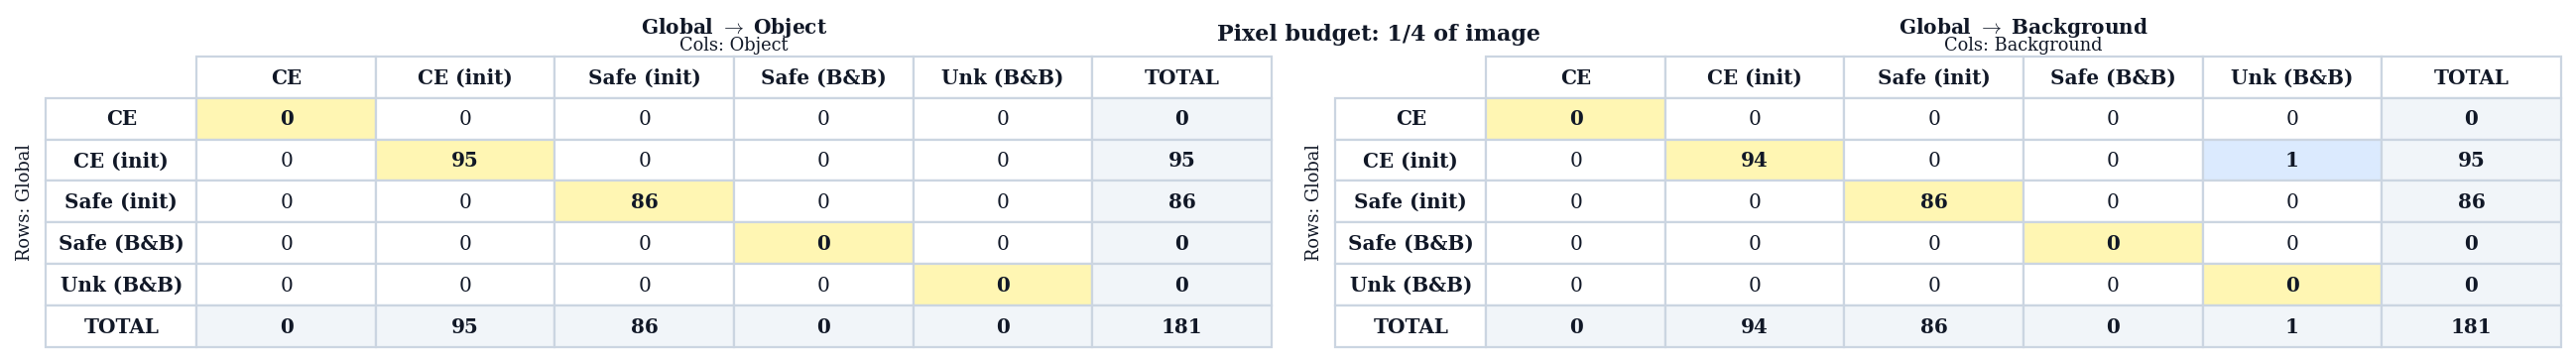

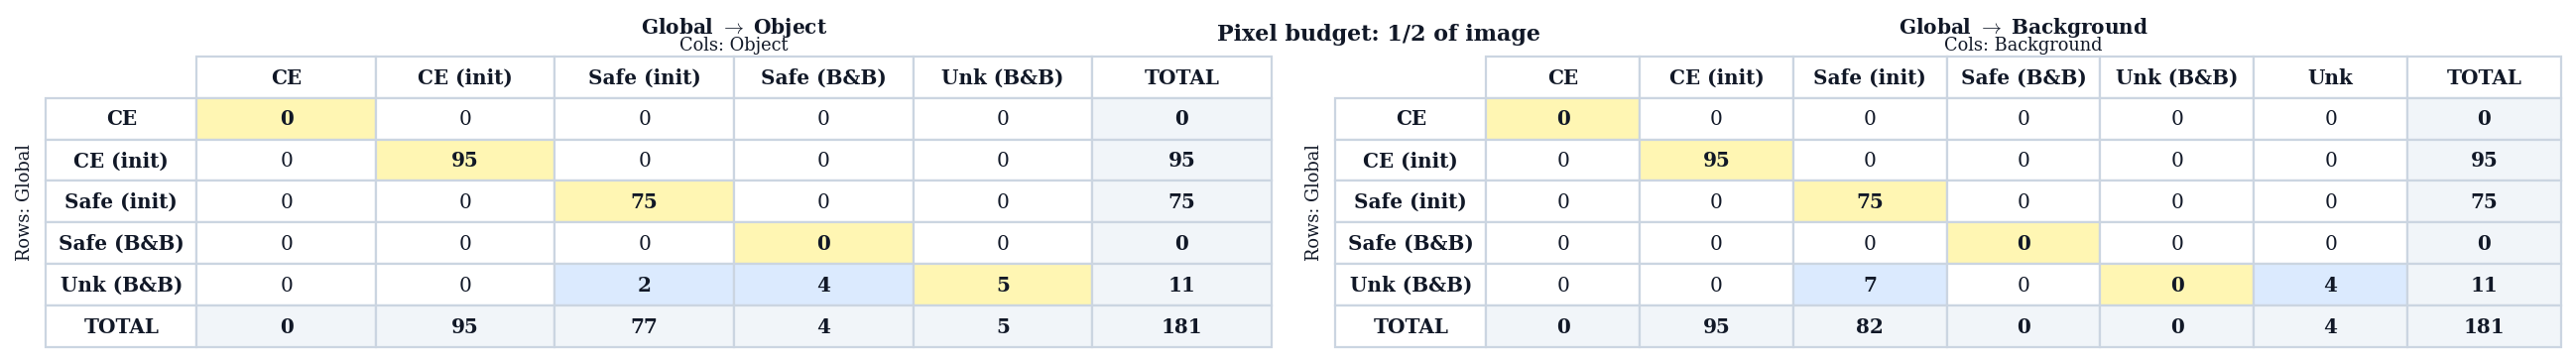

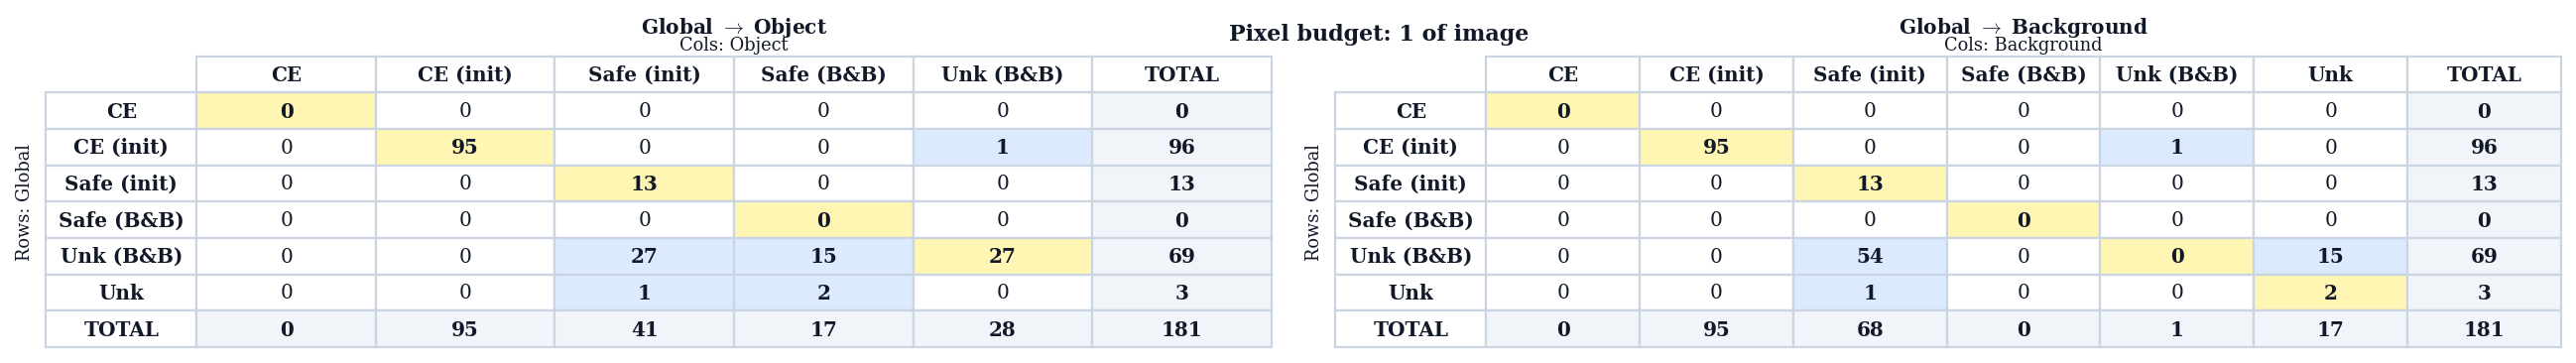

✔ Saved per-k PDFs in: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_k
✔ Saved combined PDF: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_k/transition_tables_ALL_k.pdf


In [17]:
OUT_DIR = NOTEBOOK_DIR / "paper_transition_tables_by_k"
os.makedirs(OUT_DIR, exist_ok=True)

# Colors
DIAG_COLOR    = "#fff6b3"
OFFDIAG_COLOR = "#dbeafe"
TOTAL_COLOR   = "#f1f5f9"
EDGE_COLOR    = "#cbd5e1"
TEXT_COLOR    = "#111827"

ORDER = ["Unsafe", "Safe", "Unknown"]

FULL_K = 50176   # total pixels in image

def pretty_k_label(k):
    """
    Convert k into fraction-of-image label.
    Examples:
        50176 -> "1"
        25088 -> "1/2"
        12544 -> "1/4"
        ...
    """
    ratio = FULL_K / k

    # Exact powers of two
    if ratio.is_integer():
        ratio = int(ratio)
        if ratio == 1:
            return "1"
        return f"1/{ratio}"

    # fallback: percentage
    pct = 100 * k / FULL_K
    return f"{pct:.1f}%"

def transition_crosstab(df, a="Global", b="Object", order=ORDER):
    pivot = df.pivot_table(
        index=["image", "model", "k", "eps"],
        columns="semantic",
        values="status_short",
        aggfunc="first"
    )

    t = pivot[[a, b]].dropna()
    tab = pd.crosstab(t[a], t[b], dropna=False)

    rows = list(order) + [x for x in tab.index if x not in order]
    cols = list(order) + [x for x in tab.columns if x not in order]

    tab = tab.reindex(index=rows, columns=cols, fill_value=0)

    # add totals
    tab.loc["TOTAL"] = tab.sum(axis=0)
    tab["TOTAL"] = tab.sum(axis=1)
    return tab

def style_transition_table(tab: pd.DataFrame, caption: str = ""):
    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    # diagonal mask for matching labels (excluding TOTAL row/col)
    diag = pd.DataFrame(False, index=idx, columns=cols)
    for r in idx:
        if r == "TOTAL": 
            continue
        if r in cols:
            diag.loc[r, r] = True
    # exclude TOTAL column from diag highlight
    if "TOTAL" in cols:
        diag["TOTAL"] = False
    if "TOTAL" in idx:
        diag.loc["TOTAL", :] = False

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #444",
            "padding": "6px",
            "font-size": "12px",
        })
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]},
            {"selector": "table", "props": [("border-collapse", "collapse")]}
        ])
        # diagonal highlight
        .apply(lambda _: diag.map(lambda x: "background-color: #fff6b3; font-weight: bold;" if x else ""), axis=None)
        # emphasize totals
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if s.name == "TOTAL" else "" for _ in s], axis=1)
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if c == "TOTAL" else "" for c in s.index], axis=0)
    )
    return styler

def style_transition_table(tab: pd.DataFrame, caption: str = "", diag_color="#fff6b3", offdiag_color="#dbeafe"):
    """
    tab: crosstab WITH TOTAL row/col already added.
    diag_color: diagonal highlight (same->same)
    offdiag_color: any NON-ZERO off-diagonal highlight
    """

    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    def cell_style(r, c, v):
        # base: force readability in dark themes too
        base = "background-color: white; color: #111827;"

        # totals row/col
        if r == "TOTAL" or c == "TOTAL":
            return "background-color: #f1f5f9; color: #111827; font-weight: 700;"

        # diagonal (same label), highlight
        if r == c:
            # yellow + bold + black numbers
            return f"background-color: {diag_color}; color: #111827; font-weight: 800;"

        # off-diagonal non-zero highlight
        if v != 0:
            return f"background-color: {offdiag_color}; color: #111827; font-weight: 800;"

        # zero cells: keep clean
        return base

    # Build a full style DataFrame
    styles = pd.DataFrame("", index=idx, columns=cols)
    for r in idx:
        for c in cols:
            styles.loc[r, c] = cell_style(r, c, int(tab.loc[r, c]))

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        # apply our per-cell styles
        .apply(lambda _: styles, axis=None)
        # table-level CSS (forces a nice paper look)
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-weight", "800"),
                ("text-align", "left"),
                ("color", "#111827"),
                ("font-size", "13px"),
                ("padding", "6px 0"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("background-color", "white"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "white"),
                ("color", "#111827"),
                ("font-weight", "800"),
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
                ("text-align", "center"),
            ]},
        ])
    )

    return styler

def display_with_corner_label(styler, row_label="Global status", col_label="Object status"):
    # remove the extra index/column name header rows
    styler = styler.set_table_styles([
        {"selector": "th.row_heading", "props": [("white-space", "nowrap")]},
    ], overwrite=False)

    # hide index name + columns name (prevents the extra "Global status" row)
    styler = styler.set_table_styles([], overwrite=False)
    styler = styler.set_caption(styler.caption)

    # This is the key: blank out names so pandas doesn't create that extra header row
    styler.data.index.name = None
    styler.data.columns.name = None

    # Add a combined corner label (shown as first column header area in HTML via CSS)
    corner = f"{row_label} / {col_label}"
    return styler.set_table_styles([
        # put text into the top-left corner header cell
        {"selector": "th.blank.level0", "props": [
            ("background-color", "white"),
            ("color", "#111827"),
            ("font-weight", "800"),
            ("border", "1px solid #cbd5e1"),
        ]},
    ], overwrite=False).set_properties(subset=pd.IndexSlice[:, :], **{}), corner

def _draw_df_as_table(ax, tab, fontsize=9, xscale=1.05, yscale=0.92):
    """
    Draw `tab` as a matplotlib table that fits inside the axes (no overlap).
    tab must already include TOTAL row/col.
    """
    ax.axis("off")

    row_labels = [str(x) for x in tab.index.tolist()]
    col_labels = [str(x) for x in tab.columns.tolist()]
    cell_text  = tab.values.astype(int).astype(str)

    # Table fills the axes box
    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        rowLoc="center",
        loc="center",
        bbox=[0.0, 0.0, 1.0, 1.0],   # fill panel
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)

    # Mild scaling to keep labels readable WITHOUT spilling
    tbl.scale(xscale, yscale)

    def val_at(r_i, c_j):
        return int(tab.iat[r_i, c_j])

    # Header row
    for j in range(len(col_labels)):
        cell = tbl[(0, j)]
        cell.set_facecolor("white")
        cell.set_edgecolor(EDGE_COLOR)
        cell.get_text().set_color(TEXT_COLOR)
        cell.get_text().set_weight("bold")

    # Row label column
    for i in range(1, len(row_labels) + 1):
        cell = tbl[(i, -1)]
        cell.set_facecolor("white")
        cell.set_edgecolor(EDGE_COLOR)
        cell.get_text().set_color(TEXT_COLOR)
        cell.get_text().set_weight("bold")

    # Body coloring rules
    for i_r, r in enumerate(row_labels):
        for j_c, c in enumerate(col_labels):
            v = val_at(i_r, j_c)
            cell = tbl[(i_r + 1, j_c)]
            cell.set_edgecolor(EDGE_COLOR)
            cell.get_text().set_color(TEXT_COLOR)

            if r == "TOTAL" or c == "TOTAL":
                cell.set_facecolor(TOTAL_COLOR)
                cell.get_text().set_weight("bold")
                continue

            if r == c:
                cell.set_facecolor(DIAG_COLOR)
                cell.get_text().set_weight("bold")
                continue

            if v != 0:
                cell.set_facecolor(OFFDIAG_COLOR)
                cell.get_text().set_weight("bold")
            else:
                cell.set_facecolor("white")

    return tbl

def render_transition_pair_compact(tab_GO, tab_GB, k_value, save_path_pdf,
                                  figsize=(15.2, 2.35), fontsize=9):
    """
    Compact figure, no overlap, clear axis meaning:
    Rows = Global, Columns = Object/Background
    """
    fig = plt.figure(figsize=figsize)

    # Give a bit more gap between panels to prevent collisions
    gs = GridSpec(
        1, 2, figure=fig,
        left=0.01, right=0.99,
        bottom=0.10, top=0.88,
        wspace=0.20
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])

    # Tight top title
    k_lbl = pretty_k_label(k_value)

    fig.text(
        0.5,
        0.94,
        f"Pixel budget: {k_lbl} of image",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=TEXT_COLOR,
    )

    # Panel titles
    ax0.text(0.5, 1.06, r"Global $\to$ Object", transform=ax0.transAxes,
             ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)
    ax1.text(0.5, 1.06, r"Global $\to$ Background", transform=ax1.transAxes,
             ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)

    # Axis meaning INSIDE each panel (so no extra whitespace)
    # Left side label: rows
    ax0.text(-0.16, 0.5, "Rows: Global", transform=ax0.transAxes,
             ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)
    ax1.text(-0.16, 0.5, "Rows: Global", transform=ax1.transAxes,
             ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)

    # Top label: columns
    ax0.text(0.5, 1.01, "Cols: Object", transform=ax0.transAxes,
             ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)
    ax1.text(0.5, 1.01, "Cols: Background", transform=ax1.transAxes,
             ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)

    _draw_df_as_table(ax0, tab_GO, fontsize=fontsize, xscale=1.05, yscale=0.92)
    _draw_df_as_table(ax1, tab_GB, fontsize=fontsize, xscale=1.05, yscale=0.92)

    plt.show()
    fig.savefig(save_path_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)


# ------------------------------------------------------------
# Main loop per-k
# ------------------------------------------------------------
ks = sorted(df["k"].dropna().unique())

combined_pdf_path = os.path.join(OUT_DIR, "transition_tables_ALL_k.pdf")
with PdfPages(combined_pdf_path) as pdf_pages:
    for k_val in ks:
        df_k = df[df["k"] == k_val].copy()

        tab_GO = transition_crosstab(df_k, "Global", "Object")
        tab_GB = transition_crosstab(df_k, "Global", "Background")

        per_k_pdf = os.path.join(OUT_DIR, f"transition_tables_k{k_val}.pdf")

        # Show + save
        render_transition_pair_compact(tab_GO, tab_GB, k_val, per_k_pdf,
                                       figsize=(15.2, 2.35), fontsize=9)

        # Append to combined PDF (no show)
        fig = plt.figure(figsize=(15.2, 2.35))
        gs = GridSpec(1, 2, figure=fig, left=0.01, right=0.99, bottom=0.10, top=0.88, wspace=0.10)
        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])

        k_lbl = pretty_k_label(k_val)

        fig.text(
            0.5,
            0.94,
            f"Pixel budget: {k_lbl} of image",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=TEXT_COLOR,
        )

        ax0.text(0.5, 1.06, r"Global $\to$ Object", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)
        ax1.text(0.5, 1.06, r"Global $\to$ Background", transform=ax1.transAxes,
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)

        ax0.text(-0.06, 0.5, "Rows: Global", transform=ax0.transAxes,
                 ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)
        ax1.text(-0.06, 0.5, "Rows: Global", transform=ax1.transAxes,
                 ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)

        ax0.text(0.5, 1.01, "Cols: Object", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)
        ax1.text(0.5, 1.01, "Cols: Background", transform=ax1.transAxes,
                 ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)

        _draw_df_as_table(ax0, tab_GO, fontsize=9, xscale=1.05, yscale=0.92)
        _draw_df_as_table(ax1, tab_GB, fontsize=9, xscale=1.05, yscale=0.92)

        pdf_pages.savefig(fig, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)

print(f"✔ Saved per-k PDFs in: {OUT_DIR}")
print(f"✔ Saved combined PDF: {combined_pdf_path}")

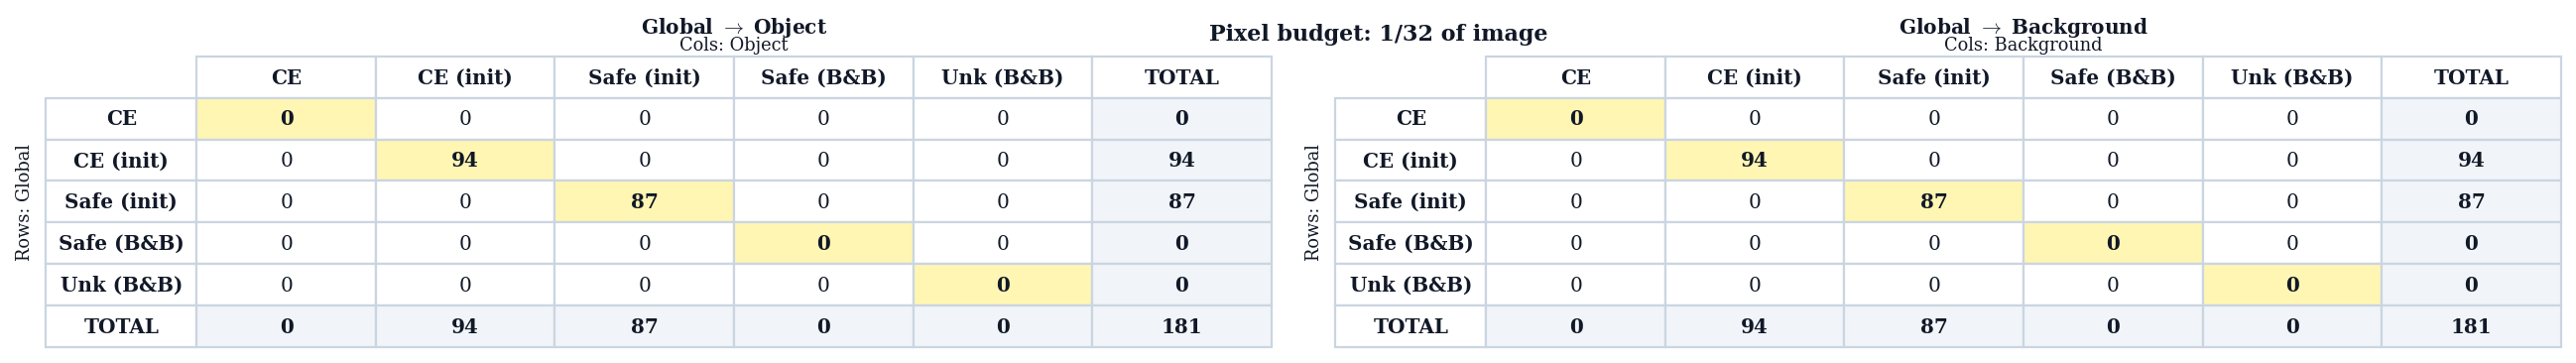

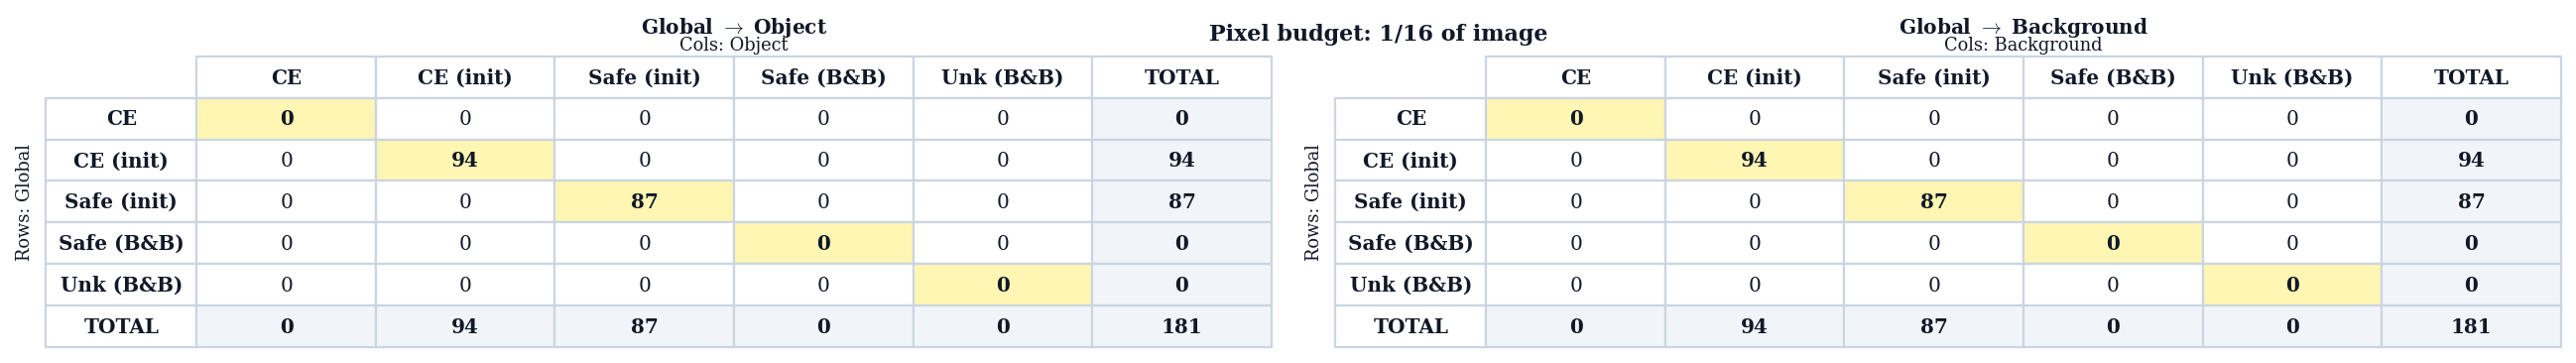

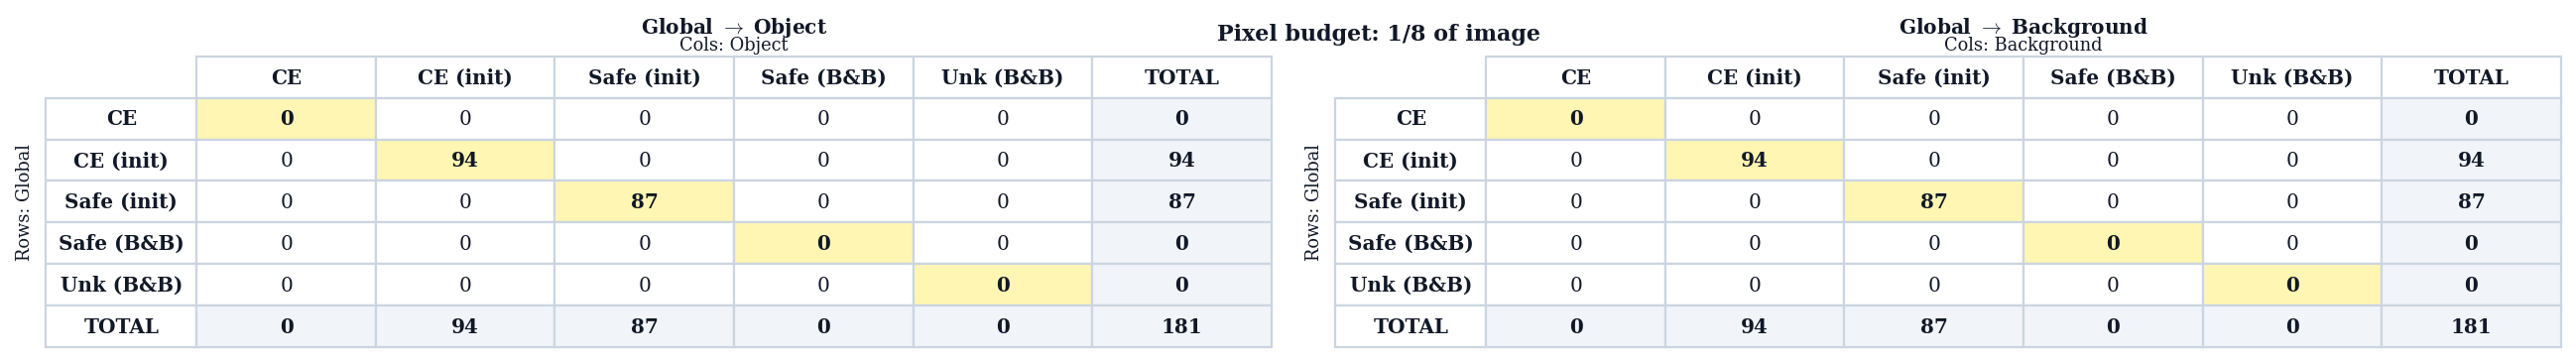

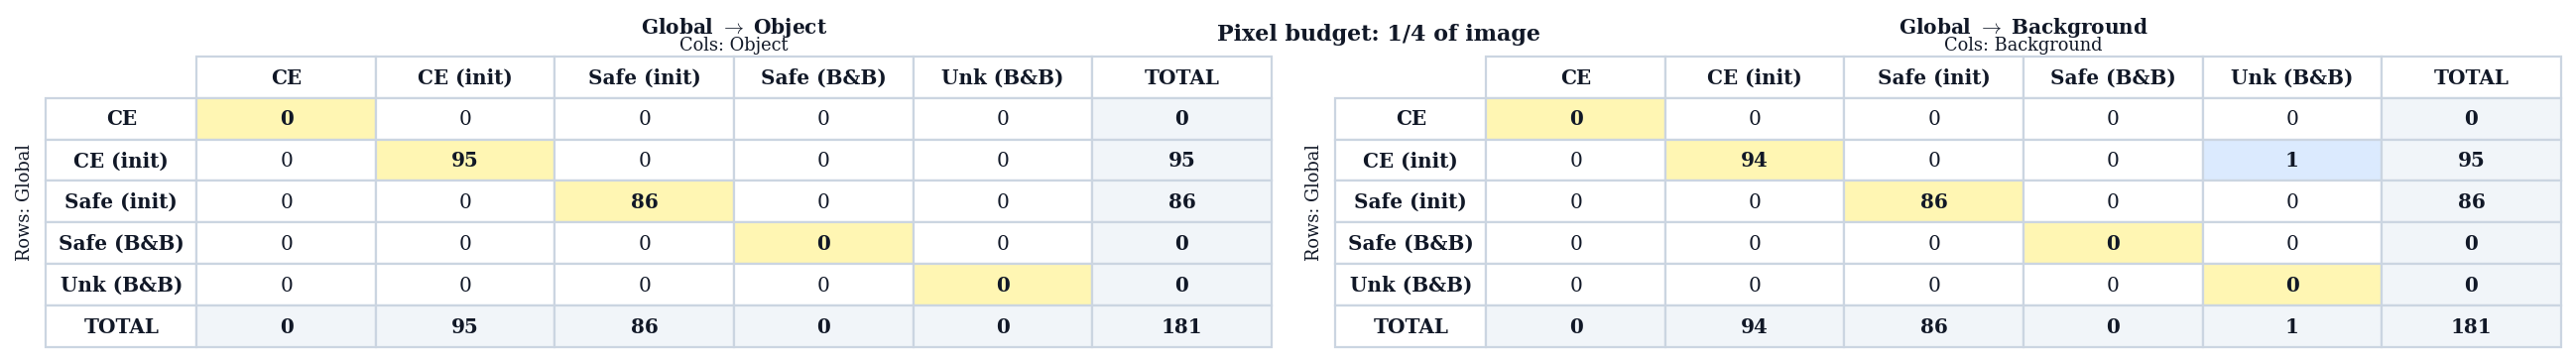

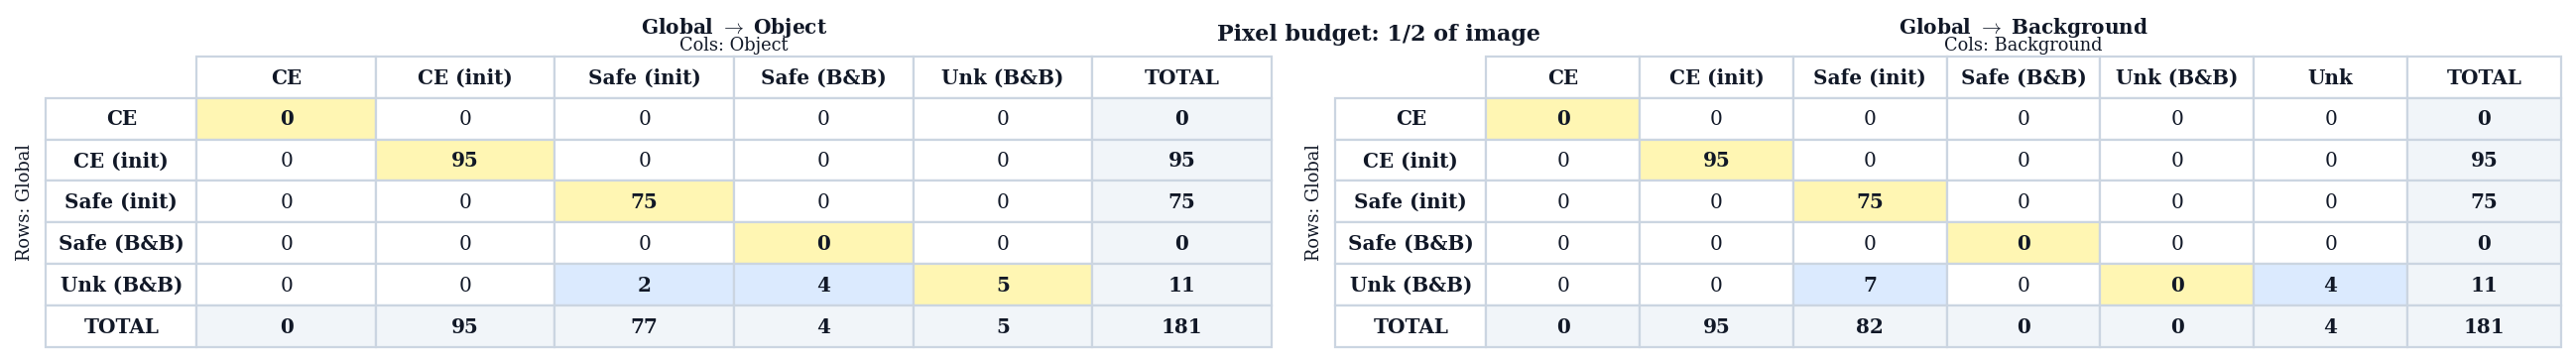

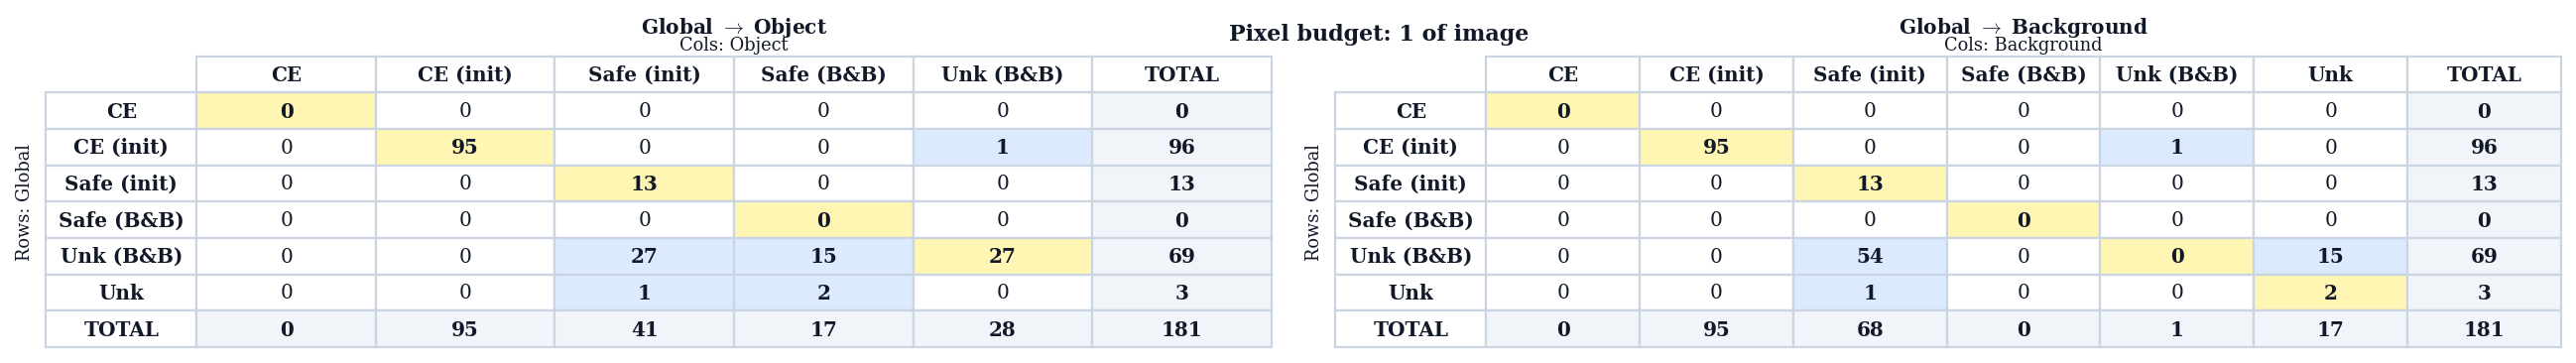

✔ Saved per-k PDFs in: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_k
✔ Saved combined PDF: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_k/transition_tables_ALL_k.pdf


In [18]:
OUT_DIR = NOTEBOOK_DIR / "paper_transition_tables_by_k"
os.makedirs(OUT_DIR, exist_ok=True)

# Colors
DIAG_COLOR    = "#fff6b3"
OFFDIAG_COLOR = "#dbeafe"
TOTAL_COLOR   = "#f1f5f9"
EDGE_COLOR    = "#cbd5e1"
TEXT_COLOR    = "#111827"

ORDER = ["Unsafe", "Safe", "Unknown"]

FULL_K = 50176   # total pixels in image

def pretty_k_label(k):
    """
    Convert k into fraction-of-image label.
    Examples:
        50176 -> "1"
        25088 -> "1/2"
        12544 -> "1/4"
        ...
    """
    ratio = FULL_K / k

    # Exact powers of two
    if ratio.is_integer():
        ratio = int(ratio)
        if ratio == 1:
            return "1"
        return f"1/{ratio}"

    # fallback: percentage
    pct = 100 * k / FULL_K
    return f"{pct:.1f}%"

def transition_crosstab(df, a="Global", b="Object", order=ORDER):
    pivot = df.pivot_table(
        index=["image", "model", "k", "eps"],
        columns="semantic",
        values="status_short",
        aggfunc="first"
    )

    t = pivot[[a, b]].dropna()
    tab = pd.crosstab(t[a], t[b], dropna=False)

    rows = list(order) + [x for x in tab.index if x not in order]
    cols = list(order) + [x for x in tab.columns if x not in order]

    tab = tab.reindex(index=rows, columns=cols, fill_value=0)

    # add totals
    tab.loc["TOTAL"] = tab.sum(axis=0)
    tab["TOTAL"] = tab.sum(axis=1)
    return tab

def style_transition_table(tab: pd.DataFrame, caption: str = ""):
    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    # diagonal mask for matching labels (excluding TOTAL row/col)
    diag = pd.DataFrame(False, index=idx, columns=cols)
    for r in idx:
        if r == "TOTAL": 
            continue
        if r in cols:
            diag.loc[r, r] = True
    # exclude TOTAL column from diag highlight
    if "TOTAL" in cols:
        diag["TOTAL"] = False
    if "TOTAL" in idx:
        diag.loc["TOTAL", :] = False

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #444",
            "padding": "6px",
            "font-size": "12px",
        })
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"), ("text-align", "left")]},
            {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]},
            {"selector": "table", "props": [("border-collapse", "collapse")]}
        ])
        # diagonal highlight
        .apply(lambda _: diag.map(lambda x: "background-color: #fff6b3; font-weight: bold;" if x else ""), axis=None)
        # emphasize totals
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if s.name == "TOTAL" else "" for _ in s], axis=1)
        .apply(lambda s: ["font-weight: bold; background-color: #eaeaea;" if c == "TOTAL" else "" for c in s.index], axis=0)
    )
    return styler

def style_transition_table(tab: pd.DataFrame, caption: str = "", diag_color="#fff6b3", offdiag_color="#dbeafe"):
    """
    tab: crosstab WITH TOTAL row/col already added.
    diag_color: diagonal highlight (same->same)
    offdiag_color: any NON-ZERO off-diagonal highlight
    """

    idx = tab.index.tolist()
    cols = tab.columns.tolist()

    def cell_style(r, c, v):
        # base: force readability in dark themes too
        base = "background-color: white; color: #111827;"

        # totals row/col
        if r == "TOTAL" or c == "TOTAL":
            return "background-color: #f1f5f9; color: #111827; font-weight: 700;"

        # diagonal (same label), highlight
        if r == c:
            # yellow + bold + black numbers
            return f"background-color: {diag_color}; color: #111827; font-weight: 800;"

        # off-diagonal non-zero highlight
        if v != 0:
            return f"background-color: {offdiag_color}; color: #111827; font-weight: 800;"

        # zero cells: keep clean
        return base

    # Build a full style DataFrame
    styles = pd.DataFrame("", index=idx, columns=cols)
    for r in idx:
        for c in cols:
            styles.loc[r, c] = cell_style(r, c, int(tab.loc[r, c]))

    styler = (
        tab.style
        .set_caption(caption)
        .format("{:d}")
        # apply our per-cell styles
        .apply(lambda _: styles, axis=None)
        # table-level CSS (forces a nice paper look)
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-weight", "800"),
                ("text-align", "left"),
                ("color", "#111827"),
                ("font-size", "13px"),
                ("padding", "6px 0"),
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("background-color", "white"),
            ]},
            {"selector": "th", "props": [
                ("background-color", "white"),
                ("color", "#111827"),
                ("font-weight", "800"),
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #cbd5e1"),
                ("padding", "6px 8px"),
                ("text-align", "center"),
            ]},
        ])
    )

    return styler

def display_with_corner_label(styler, row_label="Global status", col_label="Object status"):
    # remove the extra index/column name header rows
    styler = styler.set_table_styles([
        {"selector": "th.row_heading", "props": [("white-space", "nowrap")]},
    ], overwrite=False)

    # hide index name + columns name (prevents the extra "Global status" row)
    styler = styler.set_table_styles([], overwrite=False)
    styler = styler.set_caption(styler.caption)

    # This is the key: blank out names so pandas doesn't create that extra header row
    styler.data.index.name = None
    styler.data.columns.name = None

    # Add a combined corner label (shown as first column header area in HTML via CSS)
    corner = f"{row_label} / {col_label}"
    return styler.set_table_styles([
        # put text into the top-left corner header cell
        {"selector": "th.blank.level0", "props": [
            ("background-color", "white"),
            ("color", "#111827"),
            ("font-weight", "800"),
            ("border", "1px solid #cbd5e1"),
        ]},
    ], overwrite=False).set_properties(subset=pd.IndexSlice[:, :], **{}), corner

def _draw_df_as_table(ax, tab, fontsize=9, xscale=1.05, yscale=0.92):
    """
    Draw `tab` as a matplotlib table that fits inside the axes (no overlap).
    tab must already include TOTAL row/col.
    """
    ax.axis("off")

    row_labels = [str(x) for x in tab.index.tolist()]
    col_labels = [str(x) for x in tab.columns.tolist()]
    cell_text  = tab.values.astype(int).astype(str)

    # Table fills the axes box
    tbl = ax.table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc="center",
        rowLoc="center",
        loc="center",
        bbox=[0.0, 0.0, 1.0, 1.0],   # fill panel
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)

    # Mild scaling to keep labels readable WITHOUT spilling
    tbl.scale(xscale, yscale)

    def val_at(r_i, c_j):
        return int(tab.iat[r_i, c_j])

    # Header row
    for j in range(len(col_labels)):
        cell = tbl[(0, j)]
        cell.set_facecolor("white")
        cell.set_edgecolor(EDGE_COLOR)
        cell.get_text().set_color(TEXT_COLOR)
        cell.get_text().set_weight("bold")

    # Row label column
    for i in range(1, len(row_labels) + 1):
        cell = tbl[(i, -1)]
        cell.set_facecolor("white")
        cell.set_edgecolor(EDGE_COLOR)
        cell.get_text().set_color(TEXT_COLOR)
        cell.get_text().set_weight("bold")

    # Body coloring rules
    for i_r, r in enumerate(row_labels):
        for j_c, c in enumerate(col_labels):
            v = val_at(i_r, j_c)
            cell = tbl[(i_r + 1, j_c)]
            cell.set_edgecolor(EDGE_COLOR)
            cell.get_text().set_color(TEXT_COLOR)

            if r == "TOTAL" or c == "TOTAL":
                cell.set_facecolor(TOTAL_COLOR)
                cell.get_text().set_weight("bold")
                continue

            if r == c:
                cell.set_facecolor(DIAG_COLOR)
                cell.get_text().set_weight("bold")
                continue

            if v != 0:
                cell.set_facecolor(OFFDIAG_COLOR)
                cell.get_text().set_weight("bold")
            else:
                cell.set_facecolor("white")

    return tbl

def render_transition_pair_compact(tab_GO, tab_GB, k_value, save_path_pdf,
                                  figsize=(15.2, 2.35), fontsize=9):
    """
    Compact figure, no overlap, clear axis meaning:
    Rows = Global, Columns = Object/Background
    """
    fig = plt.figure(figsize=figsize)

    # Give a bit more gap between panels to prevent collisions
    gs = GridSpec(
        1, 2, figure=fig,
        left=0.01, right=0.99,
        bottom=0.10, top=0.88,
        wspace=0.20
    )

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])

    # Tight top title
    k_lbl = pretty_k_label(k_value)

    fig.text(
        0.5,
        0.94,
        f"Pixel budget: {k_lbl} of image",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=TEXT_COLOR,
    )

    # Panel titles
    ax0.text(0.5, 1.06, r"Global $\to$ Object", transform=ax0.transAxes,
             ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)
    ax1.text(0.5, 1.06, r"Global $\to$ Background", transform=ax1.transAxes,
             ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)

    # Axis meaning INSIDE each panel (so no extra whitespace)
    # Left side label: rows
    ax0.text(-0.16, 0.5, "Rows: Global", transform=ax0.transAxes,
             ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)
    ax1.text(-0.16, 0.5, "Rows: Global", transform=ax1.transAxes,
             ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)

    # Top label: columns
    ax0.text(0.5, 1.01, "Cols: Object", transform=ax0.transAxes,
             ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)
    ax1.text(0.5, 1.01, "Cols: Background", transform=ax1.transAxes,
             ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)

    _draw_df_as_table(ax0, tab_GO, fontsize=fontsize, xscale=1.05, yscale=0.92)
    _draw_df_as_table(ax1, tab_GB, fontsize=fontsize, xscale=1.05, yscale=0.92)

    plt.show()
    fig.savefig(save_path_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)


# ------------------------------------------------------------
# Main loop per-k
# ------------------------------------------------------------
ks = sorted(df["k"].dropna().unique())

combined_pdf_path = os.path.join(OUT_DIR, "transition_tables_ALL_k.pdf")
with PdfPages(combined_pdf_path) as pdf_pages:
    for k_val in ks:
        df_k = df[df["k"] == k_val].copy()

        tab_GO = transition_crosstab(df_k, "Global", "Object")
        tab_GB = transition_crosstab(df_k, "Global", "Background")

        per_k_pdf = os.path.join(OUT_DIR, f"transition_tables_k{k_val}.pdf")

        # Show + save
        render_transition_pair_compact(tab_GO, tab_GB, k_val, per_k_pdf,
                                       figsize=(15.2, 2.35), fontsize=9)

        # Append to combined PDF (no show)
        fig = plt.figure(figsize=(15.2, 2.35))
        gs = GridSpec(1, 2, figure=fig, left=0.01, right=0.99, bottom=0.10, top=0.88, wspace=0.10)
        ax0 = fig.add_subplot(gs[0, 0])
        ax1 = fig.add_subplot(gs[0, 1])

        k_lbl = pretty_k_label(k_val)

        fig.text(
            0.5,
            0.94,
            f"Pixel budget: {k_lbl} of image",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=TEXT_COLOR,
        )

        ax0.text(0.5, 1.06, r"Global $\to$ Object", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)
        ax1.text(0.5, 1.06, r"Global $\to$ Background", transform=ax1.transAxes,
                 ha="center", va="bottom", fontsize=9, fontweight="bold", color=TEXT_COLOR)

        ax0.text(-0.06, 0.5, "Rows: Global", transform=ax0.transAxes,
                 ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)
        ax1.text(-0.06, 0.5, "Rows: Global", transform=ax1.transAxes,
                 ha="center", va="center", rotation=90, fontsize=8, color=TEXT_COLOR)

        ax0.text(0.5, 1.01, "Cols: Object", transform=ax0.transAxes,
                 ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)
        ax1.text(0.5, 1.01, "Cols: Background", transform=ax1.transAxes,
                 ha="center", va="bottom", fontsize=8, color=TEXT_COLOR)

        _draw_df_as_table(ax0, tab_GO, fontsize=9, xscale=1.05, yscale=0.92)
        _draw_df_as_table(ax1, tab_GB, fontsize=9, xscale=1.05, yscale=0.92)

        pdf_pages.savefig(fig, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)

print(f"✔ Saved per-k PDFs in: {OUT_DIR}")
print(f"✔ Saved combined PDF: {combined_pdf_path}")

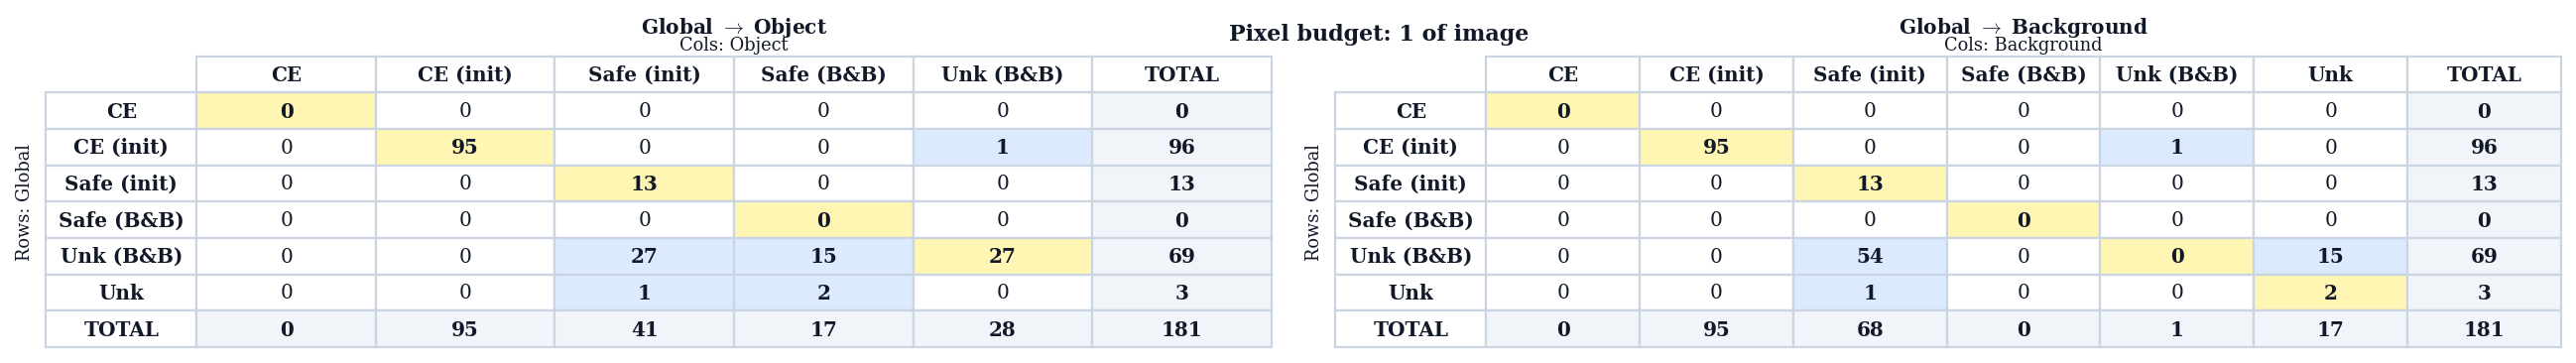

Saved per-eps PDFs in: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_eps_k50176
Saved combined PDF: /Users/zd3504phd/Desktop/XAIV/analysis/transition/paper_transition_tables_by_eps_k50176/transition_tables_k50176_ALL_eps.pdf


In [19]:
# ============================================================
# Transition tables by eps (FIXED k = 50176)
# Assumes you already created:
#   df["semantic"]      in {"Global","Object","Background"}
#   df["status_short"]  (e.g., "Unsafe", "Safe", "Unknown")
# And you already have the helper functions from your notebook:
#   transition_crosstab(...)
#   render_transition_pair_compact(...)
#   pretty_k_label(...)   (optional)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

# -------------------------
# settings
# -------------------------
K_FIXED = 50176
OUT_DIR = NOTEBOOK_DIR / "paper_transition_tables_by_eps_k50176"
os.makedirs(OUT_DIR, exist_ok=True)

# Keep Global -> Background tables in the per-eps export.
INCLUDE_BACKGROUND = True

# pick eps list (sorted)
df_k = df[df["k"].astype(float) == float(K_FIXED)].copy()
eps_list = sorted(df_k["eps"].dropna().unique())

def pretty_eps(eps):
    try:
        return f"{float(eps):g}"
    except Exception:
        return str(eps)

combined_pdf_path = os.path.join(OUT_DIR, f"transition_tables_k{K_FIXED}_ALL_eps.pdf")

with PdfPages(combined_pdf_path) as pdf_pages:
    for eps_val in eps_list:
        df_ke = df_k[df_k["eps"] == eps_val].copy()

        # --- compute transition tables
        tab_GO = transition_crosstab(df_ke, "Global", "Object")

        if INCLUDE_BACKGROUND:
            tab_GB = transition_crosstab(df_ke, "Global", "Background")

            per_eps_pdf = os.path.join(
                OUT_DIR, f"transition_tables_k{K_FIXED}_eps{pretty_eps(eps_val)}.pdf"
            )

            # show + save individual file (uses your compact renderer)
            render_transition_pair_compact(
                tab_GO, tab_GB,
                k_value=K_FIXED,
                save_path_pdf=per_eps_pdf,
                figsize=(15.2, 2.35),
                fontsize=9
            )

            # also append a page to combined PDF (no plt.show())
            fig = plt.figure(figsize=(15.2, 2.35))
            gs = GridSpec(1, 2, figure=fig, left=0.01, right=0.99, bottom=0.10, top=0.88, wspace=0.10)
            ax0 = fig.add_subplot(gs[0, 0])
            ax1 = fig.add_subplot(gs[0, 1])

            fig.text(
                0.5, 0.94,
                rf"$k={K_FIXED}$, $\epsilon={pretty_eps(eps_val)}$",
                ha="center", va="center", fontsize=10, fontweight="bold"
            )

            ax0.text(0.5, 1.06, r"Global $\to$ Object", transform=ax0.transAxes,
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
            ax1.text(0.5, 1.06, r"Global $\to$ Background", transform=ax1.transAxes,
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

            _draw_df_as_table(ax0, tab_GO, fontsize=9, xscale=1.05, yscale=0.92)
            _draw_df_as_table(ax1, tab_GB, fontsize=9, xscale=1.05, yscale=0.92)

            pdf_pages.savefig(fig, bbox_inches="tight", pad_inches=0.02)
            plt.close(fig)

        else:
            # Only Global -> Object (single table per eps)
            per_eps_pdf = os.path.join(
                OUT_DIR, f"transition_table_Global_to_Object_k{K_FIXED}_eps{pretty_eps(eps_val)}.pdf"
            )

            fig = plt.figure(figsize=(7.6, 2.35))
            ax = fig.add_subplot(111)

            fig.text(
                0.5, 0.94,
                rf"Global $\to$ Object ($k={K_FIXED},\ \epsilon={pretty_eps(eps_val)}$)",
                ha="center", va="center", fontsize=10, fontweight="bold"
            )

            _draw_df_as_table(ax, tab_GO, fontsize=9, xscale=1.08, yscale=0.92)

            # save individual + append to combined
            fig.savefig(per_eps_pdf, bbox_inches="tight", pad_inches=0.02)
            pdf_pages.savefig(fig, bbox_inches="tight", pad_inches=0.02)
            plt.close(fig)

print(f"Saved per-eps PDFs in: {OUT_DIR}")
print(f"Saved combined PDF: {combined_pdf_path}")